In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder,  LabelEncoder
import csv
import requests
!pip install beautifulsoup4

In [ ]:
import requests
url='https://en.wikipedia.org/wiki/List_of_largest_companies_in_India'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/74.0.3729.169 Safari/537.36'}
response=requests.get(url, headers=headers)
response.status_code

200

In [ ]:
from bs4 import BeautifulSoup
soup=BeautifulSoup(response.text,'html')
print(soup)

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>List of largest companies in India - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-conten

In [ ]:
table=soup.find('table')
print(table)

<table class="wikitable sortable" style="text-align:right;">
<tbody><tr>
<th align="center">Rank
</th>
<th align="center">Forbes<br/> 2000 rank
</th>
<th align="center">Name
</th>
<th align="center">Headquarters
</th>
<th align="center">Revenue<br/>(billions US$)
</th>
<th align="center">Profit<br/>(billions US$)
</th>
<th align="center">Assets<br/>(billions US$)
</th>
<th align="center">Value<br/>(billions US$)
</th>
<th align="center">Industry
</th></tr>
<tr>
<td>1
</td>
<td>49
</td>
<td align="left"><a class="mw-redirect" href="/wiki/Reliance_Industries_Limited" title="Reliance Industries Limited">Reliance Industries Limited</a>
</td>
<td align="left">Mumbai
</td>
<td>108.8
</td>
<td>8.4
</td>
<td>210.5
</td>
<td>233.1
</td>
<td align="left"><a href="/wiki/Conglomerate_(company)" title="Conglomerate (company)">Conglomerate</a>
</td></tr>
<tr>
<td>2
</td>
<td>55
</td>
<td align="left"><a href="/wiki/State_Bank_of_India" title="State Bank of India">State Bank of India</a>
</td>
<td al

In [ ]:
table.find_all('th')

[<th align="center">Rank
 </th>,
 <th align="center">Forbes<br/> 2000 rank
 </th>,
 <th align="center">Name
 </th>,
 <th align="center">Headquarters
 </th>,
 <th align="center">Revenue<br/>(billions US$)
 </th>,
 <th align="center">Profit<br/>(billions US$)
 </th>,
 <th align="center">Assets<br/>(billions US$)
 </th>,
 <th align="center">Value<br/>(billions US$)
 </th>,
 <th align="center">Industry
 </th>]

In [ ]:
titles=table.find_all('th')
titles

[<th align="center">Rank
 </th>,
 <th align="center">Forbes<br/> 2000 rank
 </th>,
 <th align="center">Name
 </th>,
 <th align="center">Headquarters
 </th>,
 <th align="center">Revenue<br/>(billions US$)
 </th>,
 <th align="center">Profit<br/>(billions US$)
 </th>,
 <th align="center">Assets<br/>(billions US$)
 </th>,
 <th align="center">Value<br/>(billions US$)
 </th>,
 <th align="center">Industry
 </th>]

In [ ]:
tables_titles=[title.text for title in titles]
print(tables_titles)

['Rank\n', 'Forbes 2000 rank\n', 'Name\n', 'Headquarters\n', 'Revenue(billions US$)\n', 'Profit(billions US$)\n', 'Assets(billions US$)\n', 'Value(billions US$)\n', 'Industry\n']


In [ ]:
tables_titles=[title.text.strip() for title in titles]
print(tables_titles)

['Rank', 'Forbes 2000 rank', 'Name', 'Headquarters', 'Revenue(billions US$)', 'Profit(billions US$)', 'Assets(billions US$)', 'Value(billions US$)', 'Industry']


In [ ]:
df=pd.DataFrame(columns=tables_titles)
df

,Rank,Forbes 2000 rank,Name,Headquarters,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry


In [ ]:
column_data=table.find_all('tr')

In [ ]:
for row in column_data:
  row_data=row.find_all('td')
  individual_row_data=[data.text.strip() for data in row_data]
  print(individual_row_data)

[]
['1', '49', 'Reliance Industries Limited', 'Mumbai', '108.8', '8.4', '210.5', '233.1', 'Conglomerate']
['2', '55', 'State Bank of India', 'Mumbai', '71.8', '8.1', '807.4', '87.6', 'Banking']
['3', '65', 'HDFC Bank', 'Mumbai', '49.3', '7.7', '483.2', '133.6', 'Banking']
['4', '70', 'Life Insurance Corporation', 'New Delhi', '98.0', '4.9', '561.4', '73.6', 'Insurance']
['5', '142', 'ICICI Bank', 'Mumbai', '28.5', '5.3', '283.5', '95.3', 'Banking']
['6', '207', 'Oil and Natural Gas Corporation', 'New Delhi', '77.5', '5.1', '80.6', '41.9', 'Oil and gas']
['7', '259', 'Indian Oil Corporation', 'New Delhi', '93.8', '5.0', '57.8', '27.8', 'Oil and gas']
['8', '284', 'Tata Motors', 'Mumbai', '52.9', '3.8', '44.4', '43.8', 'Automotive']
['9', '293', 'Axis Bank', 'Mumbai', '16.7', '3.2', '182.0', '42.3', 'Banking']
['10', '372', 'NTPC Limited', 'New Delhi', '21.2', '2.4', '54.7', '42.5', 'Utilities']
['11', '398', 'Larsen & Toubro', 'Mumbai', '26.7', '1.6', '40.7', '56.9', 'Capital goods']
['

In [ ]:
for row in column_data[1:]:
  row_data=row.find_all('td')
  individual_row_data=[data.text.strip() for data in row_data]
  length=len(df)
  df.loc[length]=individual_row_data
  #print(individual_row_data)
df

,Rank,Forbes 2000 rank,Name,Headquarters,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry
0,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate
1,2,55,State Bank of India,Mumbai,71.8,8.1,807.4,87.6,Banking
2,3,65,HDFC Bank,Mumbai,49.3,7.7,483.2,133.6,Banking
3,4,70,Life Insurance Corporation,New Delhi,98.0,4.9,561.4,73.6,Insurance
4,5,142,ICICI Bank,Mumbai,28.5,5.3,283.5,95.3,Banking
...,...,...,...,...,...,...,...,...,...
66,65,1895,Dr. Reddy's Laboratories,Hyderabad,3.4,0.7,4.6,11.6,Pharmaceuticals
67,66,1908,Varun Beverages,Gurgaon,2.0,0.3,1.8,23.6,Beverages
68,67,1949,CIFCL,Chennai,2.3,0.4,18.8,13.0,Financials
69,68,1957,NMDC,Hyderabad,2.5,0.8,3.9,9.7,Mining


Rank                     0
Forbes 2000 rank         0
Name                     0
Headquarters             0
Revenue(billions US$)    0
Profit(billions US$)     0
Assets(billions US$)     0
Value(billions US$)      0
Industry                 0
dtype: int64


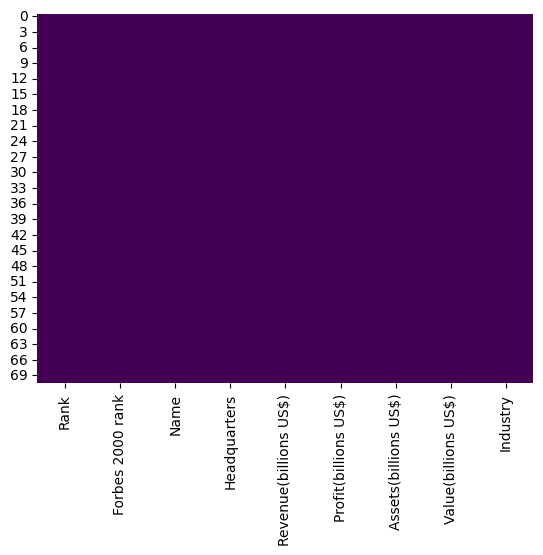

In [ ]:
print(df.isnull().sum())
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.show()
df.dropna(inplace=True)

In [ ]:
df.fillna(0, inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Industry_LabelEncoded'] = label_encoder.fit_transform(df['Industry'])
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_mapping_df = pd.DataFrame(list(label_mapping.items()), columns=['Industry', 'Label Encoded Value'])
display(label_mapping_df)

,Industry,Label Encoded Value
0,Aerospace and defense,0
1,Airline,1
2,Automotive,2
3,Banking,3
4,Beverages,4
5,Capital goods,5
6,Chemicals,6
7,Conglomerate,7
8,Consumer Goods,8
9,Diversified,9


In [ ]:
# Perform one-hot encoding on the 'Industry' column
onehot_encoder = OneHotEncoder(sparse_output=False)
encoded_array = onehot_encoder.fit_transform(df[['Industry']])
feature_names = onehot_encoder.get_feature_names_out(['Industry'])
# Create a DataFrame from the one-hot encoded array
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)
# Concatenate the new one-hot encoded DataFrame with the original DataFrame
df = pd.concat([df, encoded_df], axis=1)
# Optionally drop the original 'Industry' column if you no longer need it
# df = df.drop('Industry', axis=1)
display(df.head(17))

,Rank,Forbes 2000 rank,Name,Headquarters,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry,Industry_LabelEncoded,...,Industry_Metals and mining,Industry_Mining,Industry_Oil and gas,Industry_Pharmaceuticals,Industry_Real estate,Industry_Renewable energy,Industry_Retail,Industry_Shipping,Industry_Telecommunication,Industry_Utilities
0,1,49,Reliance Industries Limited,Mumbai,108.8,8.4,210.5,233.1,Conglomerate,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,55,State Bank of India,Mumbai,71.8,8.1,807.4,87.6,Banking,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,65,HDFC Bank,Mumbai,49.3,7.7,483.2,133.6,Banking,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,70,Life Insurance Corporation,New Delhi,98.0,4.9,561.4,73.6,Insurance,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,142,ICICI Bank,Mumbai,28.5,5.3,283.5,95.3,Banking,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,6,207,Oil and Natural Gas Corporation,New Delhi,77.5,5.1,80.6,41.9,Oil and gas,19,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,7,259,Indian Oil Corporation,New Delhi,93.8,5.0,57.8,27.8,Oil and gas,19,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8,284,Tata Motors,Mumbai,52.9,3.8,44.4,43.8,Automotive,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,293,Axis Bank,Mumbai,16.7,3.2,182.0,42.3,Banking,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,372,NTPC Limited,New Delhi,21.2,2.4,54.7,42.5,Utilities,26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Apply cleaning operations to string columns
for col in ['Name', 'Headquarters', 'Industry']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: x.split('[')[0] if isinstance(x, str) else x)
        df[col] = df[col].replace(r'\n', '', regex=True)
        df[col] = df[col].apply(lambda x: x.lower() if isinstance(x, str) else x)
        df[col] = df[col].apply(lambda x: ' '.join(x.split()) if isinstance(x, str) else x)
print("\nCleaned Data:")
one_hot_columns = [col for col in df.columns if col.startswith('Industry_')]
columns_to_display = ['Name', 'Industry_LabelEncoded'] + one_hot_columns[:5] # Displaying first 5 one-hot columns
display(df[columns_to_display].head())
cleaned_filename = 'largest_indian_companies_cleaned.csv'
df.to_csv(cleaned_filename, index=False)
print(f"\nCleaned data saved as '{cleaned_filename}'.")


Cleaned Data:


,Name,Industry_LabelEncoded,Industry_LabelEncoded,Industry_Aerospace and defense,Industry_Airline,Industry_Automotive,Industry_Banking
0,reliance industries limited,7,7,0.0,0.0,0.0,0.0
1,state bank of india,3,3,0.0,0.0,0.0,1.0
2,hdfc bank,3,3,0.0,0.0,0.0,1.0
3,life insurance corporation,15,15,0.0,0.0,0.0,0.0
4,icici bank,3,3,0.0,0.0,0.0,1.0



Cleaned data saved as 'largest_indian_companies_cleaned.csv'.


In [ ]:
# Identify numerical features (excluding the encoded ones if not intended for scaling this way)
# For this example, we'll scale the original numerical columns and the label encoded column.
# One-hot encoded columns are already in a suitable scale (0 or 1).
numerical_features_to_scale = ['Rank', 'Forbes 2000 rank', 'Revenue(billions US$)', 'Profit(billions US$)', 'Assets(billions US$)', 'Value(billions US$)', 'Industry_LabelEncoded']
# Ensure the columns to scale exist in the DataFrame
numerical_features_to_scale = [col for col in numerical_features_to_scale if col in df.columns]
if len(numerical_features_to_scale) > 0:
    # Clean numerical columns: replace hyphen-minus with minus and convert to numeric
    for col in numerical_features_to_scale:
        if df[col].dtype == 'object': # Only attempt to clean if the column is of object type (likely strings)
             df[col] = df[col].astype(str).str.replace('−', '-', regex=False)
             df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric, coercing errors
    # Drop rows where numerical columns became NaN after coercion, if any
    df.dropna(subset=numerical_features_to_scale, inplace=True)
    scaler = MinMaxScaler()
    df_normalized = pd.DataFrame(scaler.fit_transform(df[numerical_features_to_scale]),
                                  columns=numerical_features_to_scale,
                                  index=df.index)
    # Drop the original numerical columns and concatenate the normalized ones
    df = df.drop(columns=numerical_features_to_scale).reset_index(drop=True).merge(df_normalized.reset_index(drop=True), left_index=True, right_index=True)
else:
    print("No numerical features found for scaling from the specified list.")
display(df.head())

,Name,Headquarters,Industry,Industry_Aerospace and defense,Industry_Airline,Industry_Automotive,Industry_Banking,Industry_Beverages,Industry_Capital goods,Industry_Chemicals,...,Industry_Shipping,Industry_Telecommunication,Industry_Utilities,Rank,Forbes 2000 rank,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry_LabelEncoded
0,reliance industries limited,mumbai,conglomerate,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,1.000000,1.000000,0.259521,1.000000,0.269231
1,state bank of india,mumbai,banking,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.014706,0.003107,0.659300,0.965909,1.000000,0.372845,0.115385
2,hdfc bank,mumbai,banking,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.029412,0.008286,0.452118,0.920455,0.597817,0.571121,0.115385
3,life insurance corporation,new delhi,insurance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.044118,0.010875,0.900552,0.602273,0.694827,0.312500,0.576923
4,icici bank,mumbai,banking,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.058824,0.048162,0.260589,0.647727,0.350081,0.406034,0.115385


In [ ]:
from sklearn.preprocessing import StandardScaler
# Identify numerical features (excluding the encoded ones if not intended for scaling this way)
# For this example, we'll scale the original numerical columns and the label encoded column.
# One-hot encoded columns are already in a suitable scale (0 or 1).
numerical_features_to_scale = ['Rank', 'Forbes 2000 rank', 'Revenue(billions US$)', 'Profit(billions US$)', 'Assets(billions US$)', 'Value(billions US$)', 'Industry_LabelEncoded']
# Ensure the columns to scale exist in the DataFrame
numerical_features_to_scale = [col for col in numerical_features_to_scale if col in df.columns]
if len(numerical_features_to_scale) > 0:
    # Clean numerical columns: replace hyphen-minus with minus and convert to numeric
    for col in numerical_features_to_scale:
        if df[col].dtype == 'object': # Only attempt to clean if the column is of object type (likely strings)
             df[col] = df[col].astype(str).str.replace('−', '-', regex=False)
             df[col] = pd.to_numeric(df[col], errors='coerce') # Convert to numeric, coercing errors
    # Drop rows where numerical columns became NaN after coercion, if any
    df.dropna(subset=numerical_features_to_scale, inplace=True)
    scaler = StandardScaler()
    df_standardized = pd.DataFrame(scaler.fit_transform(df[numerical_features_to_scale]),
                                  columns=numerical_features_to_scale,
                                  index=df.index)
    # Drop the original numerical columns and concatenate the standardized ones
    df = df.drop(columns=numerical_features_to_scale).reset_index(drop=True).merge(df_standardized.reset_index(drop=True), left_index=True, right_index=True)
else:
    print("No numerical features found for scaling from the specified list.")
display(df.head())

,Name,Headquarters,Industry,Industry_Aerospace and defense,Industry_Airline,Industry_Automotive,Industry_Banking,Industry_Beverages,Industry_Capital goods,Industry_Chemicals,...,Industry_Shipping,Industry_Telecommunication,Industry_Utilities,Rank,Forbes 2000 rank,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry_LabelEncoded
0,reliance industries limited,mumbai,conglomerate,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.739541,-1.652597,3.924829,3.497168,1.053773,5.301358,-0.546447
1,state bank of india,mumbai,banking,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.688986,-1.642674,2.328797,3.340645,5.582879,1.435172,-1.068976
2,hdfc bank,mumbai,banking,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.638430,-1.626136,1.358237,3.131946,3.122943,2.657472,-1.068976
3,life insurance corporation,new delhi,insurance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.587874,-1.617867,3.458960,1.671057,3.716302,1.063168,0.498610
4,icici bank,mumbai,banking,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.537319,-1.498793,0.461008,1.879756,1.607676,1.639775,-1.068976


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
print(df.head())

                          Name Headquarters      Industry  \
0  reliance industries limited       mumbai  conglomerate   
1          state bank of india       mumbai       banking   
2                    hdfc bank       mumbai       banking   
3   life insurance corporation    new delhi     insurance   
4                   icici bank       mumbai       banking   

   Industry_Aerospace and defense  Industry_Airline  Industry_Automotive  \
0                             0.0               0.0                  0.0   
1                             0.0               0.0                  0.0   
2                             0.0               0.0                  0.0   
3                             0.0               0.0                  0.0   
4                             0.0               0.0                  0.0   

   Industry_Banking  Industry_Beverages  Industry_Capital goods  \
0               0.0                 0.0                     0.0   
1               1.0                 0.0   

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Name                            71 non-null     object 
 1   Headquarters                    71 non-null     object 
 2   Industry                        71 non-null     object 
 3   Industry_Aerospace and defense  71 non-null     float64
 4   Industry_Airline                71 non-null     float64
 5   Industry_Automotive             71 non-null     float64
 6   Industry_Banking                71 non-null     float64
 7   Industry_Beverages              71 non-null     float64
 8   Industry_Capital goods          71 non-null     float64
 9   Industry_Chemicals              71 non-null     float64
 10  Industry_Conglomerate           71 non-null     float64
 11  Industry_Consumer Goods         71 non-null     float64
 12  Industry_Diversified            71 non

In [ ]:
print(df.isnull().sum())

Name                              0
Headquarters                      0
Industry                          0
Industry_Aerospace and defense    0
Industry_Airline                  0
Industry_Automotive               0
Industry_Banking                  0
Industry_Beverages                0
Industry_Capital goods            0
Industry_Chemicals                0
Industry_Conglomerate             0
Industry_Consumer Goods           0
Industry_Diversified              0
Industry_Energy                   0
Industry_Financials               0
Industry_Gems and jewellery       0
Industry_Holding                  0
Industry_Infotech                 0
Industry_Insurance                0
Industry_Iron and steel           0
Industry_Metals and mining        0
Industry_Mining                   0
Industry_Oil and gas              0
Industry_Pharmaceuticals          0
Industry_Real estate              0
Industry_Renewable energy         0
Industry_Retail                   0
Industry_Shipping           

In [ ]:
desc_stats = df.describe()
print(desc_stats)

       Industry_Aerospace and defense  Industry_Airline  Industry_Automotive  \
count                       71.000000         71.000000            71.000000   
mean                         0.014085          0.014085             0.056338   
std                          0.118678          0.118678             0.232214   
min                          0.000000          0.000000             0.000000   
25%                          0.000000          0.000000             0.000000   
50%                          0.000000          0.000000             0.000000   
75%                          0.000000          0.000000             0.000000   
max                          1.000000          1.000000             1.000000   

       Industry_Banking  Industry_Beverages  Industry_Capital goods  \
count         71.000000           71.000000               71.000000   
mean           0.239437            0.014085                0.028169   
std            0.429777            0.118678                0.16663

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
skewness = df[numerical_cols].skew()
kurtosis = df[numerical_cols].kurt()
print("Skewness:\n", skewness)
print("Kurtosis:\n", kurtosis)

Skewness:
 Industry_Aerospace and defense    8.426150
Industry_Airline                  8.426150
Industry_Automotive               3.931898
Industry_Banking                  1.247698
Industry_Beverages                8.426150
Industry_Capital goods            5.827260
Industry_Chemicals                8.426150
Industry_Conglomerate             8.426150
Industry_Consumer Goods           8.426150
Industry_Diversified              8.426150
Industry_Energy                   8.426150
Industry_Financials               2.751471
Industry_Gems and jewellery       5.827260
Industry_Holding                  5.827260
Industry_Infotech                 3.931898
Industry_Insurance                5.827260
Industry_Iron and steel           3.931898
Industry_Metals and mining        4.649726
Industry_Mining                   8.426150
Industry_Oil and gas              3.931898
Industry_Pharmaceuticals          5.827260
Industry_Real estate              8.426150
Industry_Renewable energy         8.426150


In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
# Identify unique one-hot encoded columns
one_hot_columns = [col for col in df.columns if col.startswith('Industry_')]
# Keep only one instance of each one-hot encoded category if duplicates exist
unique_one_hot_columns = list(dict.fromkeys(one_hot_columns))
# Combine unique numerical columns and unique one-hot encoded columns
# Ensure 'Industry_LabelEncoded' is included if it's in numerical_cols and not in one_hot_columns
final_cols = [col for col in numerical_cols if col not in one_hot_columns] + unique_one_hot_columns
# Select only the final unique columns for correlation calculation
df_unique_cols = df[final_cols]
correlation_matrix = df_unique_cols.corr()
correlation_matrix

,Rank,Forbes 2000 rank,Revenue(billions US$),Profit(billions US$),Assets(billions US$),Value(billions US$),Industry_Aerospace and defense,Industry_Airline,Industry_Automotive,Industry_Banking,...,Industry_Mining,Industry_Oil and gas,Industry_Pharmaceuticals,Industry_Real estate,Industry_Renewable energy,Industry_Retail,Industry_Shipping,Industry_Telecommunication,Industry_Utilities,Industry_LabelEncoded
Rank,1.000000,0.991674,-0.683083,-0.761417,-0.546780,-0.579504,0.136511,0.039830,-0.023575,-0.178445,...,0.196936,-0.230482,0.151413,0.172766,0.106298,0.088170,0.045872,0.022306,-0.064511,0.075408
Forbes 2000 rank,0.991674,1.000000,-0.663659,-0.742569,-0.539910,-0.564942,0.152744,0.032365,-0.024960,-0.176445,...,0.179627,-0.228318,0.135075,0.163023,0.128629,0.112420,0.033748,0.031460,-0.047683,0.082210
Revenue(billions US$),-0.683083,-0.663659,1.000000,0.796867,0.573631,0.585903,-0.080495,-0.051107,0.040181,-0.030632,...,-0.078948,0.448598,-0.097401,-0.087713,-0.086166,-0.060387,-0.075339,-0.051501,-0.058101,0.025209
Profit(billions US$),-0.761417,-0.742569,0.796867,1.000000,0.690720,0.772365,-0.080893,-0.049713,-0.015576,0.166138,...,-0.055949,0.245764,-0.070812,-0.087129,-0.099601,-0.087129,-0.043477,-0.079695,-0.010650,-0.101336
Assets(billions US$),-0.546780,-0.539910,0.573631,0.690720,1.000000,0.422375,-0.060963,-0.056973,-0.092552,0.466239,...,-0.061417,-0.050421,-0.083350,-0.058424,-0.055340,-0.062686,-0.051985,-0.053767,-0.060489,-0.278402
Value(billions US$),-0.579504,-0.564942,0.585903,0.772365,0.422375,1.000000,-0.037440,-0.042522,-0.021352,-0.043331,...,-0.075869,-0.052192,-0.025961,-0.026642,0.003847,0.009564,0.003212,0.080123,-0.012216,-0.010568
Industry_Aerospace and defense,0.136511,0.152744,-0.080495,-0.080893,-0.060963,-0.037440,1.000000,-0.014286,-0.029204,-0.067062,...,-0.014286,-0.029204,-0.020349,-0.014286,-0.014286,-0.014286,-0.014286,-0.020349,-0.025105,-0.174608
Industry_Airline,0.039830,0.032365,-0.051107,-0.049713,-0.056973,-0.042522,-0.014286,1.000000,-0.029204,-0.067062,...,-0.014286,-0.029204,-0.020349,-0.014286,-0.014286,-0.014286,-0.014286,-0.020349,-0.025105,-0.158994
Industry_Automotive,-0.023575,-0.024960,0.040181,-0.015576,-0.092552,-0.021352,-0.029204,-0.029204,1.000000,-0.137095,...,-0.029204,-0.059701,-0.041599,-0.029204,-0.029204,-0.029204,-0.029204,-0.041599,-0.051321,-0.293111
Industry_Banking,-0.178445,-0.176445,-0.030632,0.166138,0.466239,-0.043331,-0.067062,-0.067062,-0.137095,1.000000,...,-0.067062,-0.137095,-0.095525,-0.067062,-0.067062,-0.067062,-0.067062,-0.095525,-0.117851,-0.599785


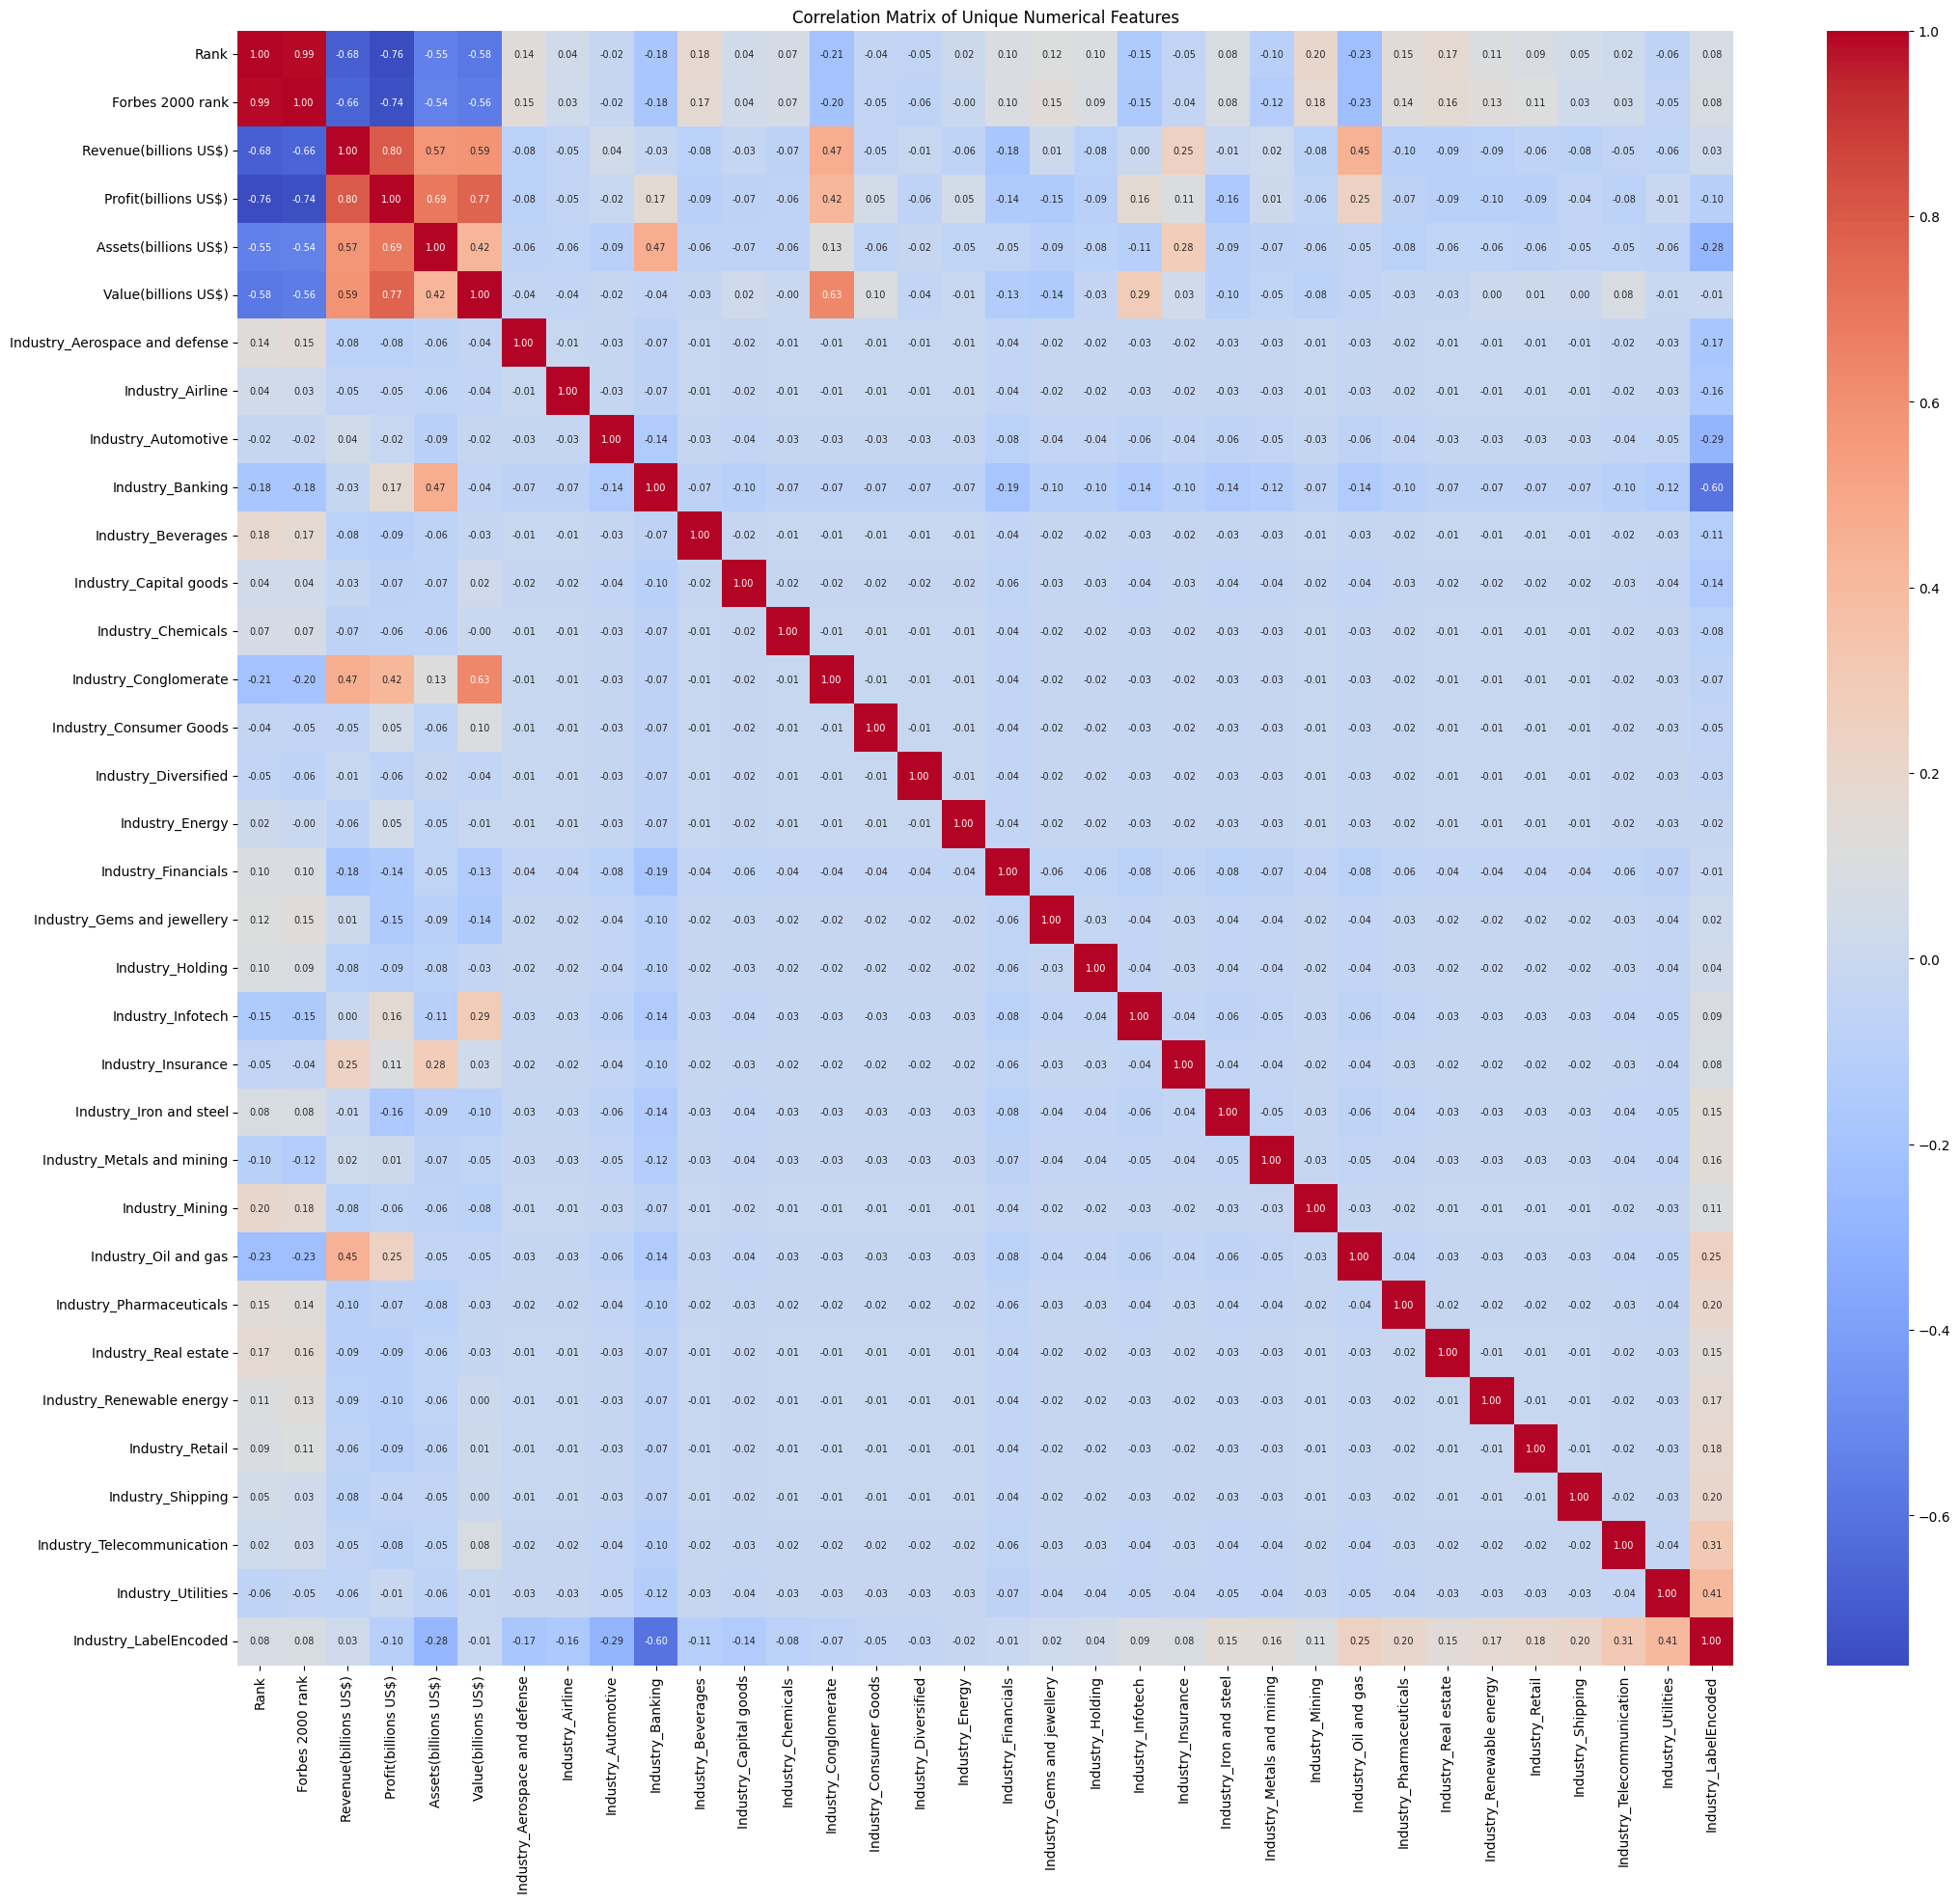

In [ ]:
# Remove duplicate columns from the correlation matrix for cleaner visualization
# This assumes that if two columns have a correlation of 1.0, they are duplicates
# We keep track of columns to keep and iterate through them
# cols_to_keep = []
# cols_seen = set()
# for col in correlation_matrix.columns:
#     # Check if this column is highly correlated (correlation ~ 1.0) with a column already seen
#     is_duplicate = False
#     for seen_col in cols_seen:
#         if abs(correlation_matrix.loc[col, seen_col] - 1.0) < 1e-9: # Check for correlation very close to 1
#             is_duplicate = True
#             break
#     if not is_duplicate:
#         cols_to_keep.append(col)
#         cols_seen.add(col)
# Filter the correlation matrix to keep only the unique columns
# cleaned_correlation_matrix = correlation_matrix.loc[cols_to_keep, cols_to_keep]
plt.figure(figsize=(25, 22)) # Further increased figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 7}) # Reduced annotation font size
plt.title('Correlation Matrix of Unique Numerical Features')
plt.show()

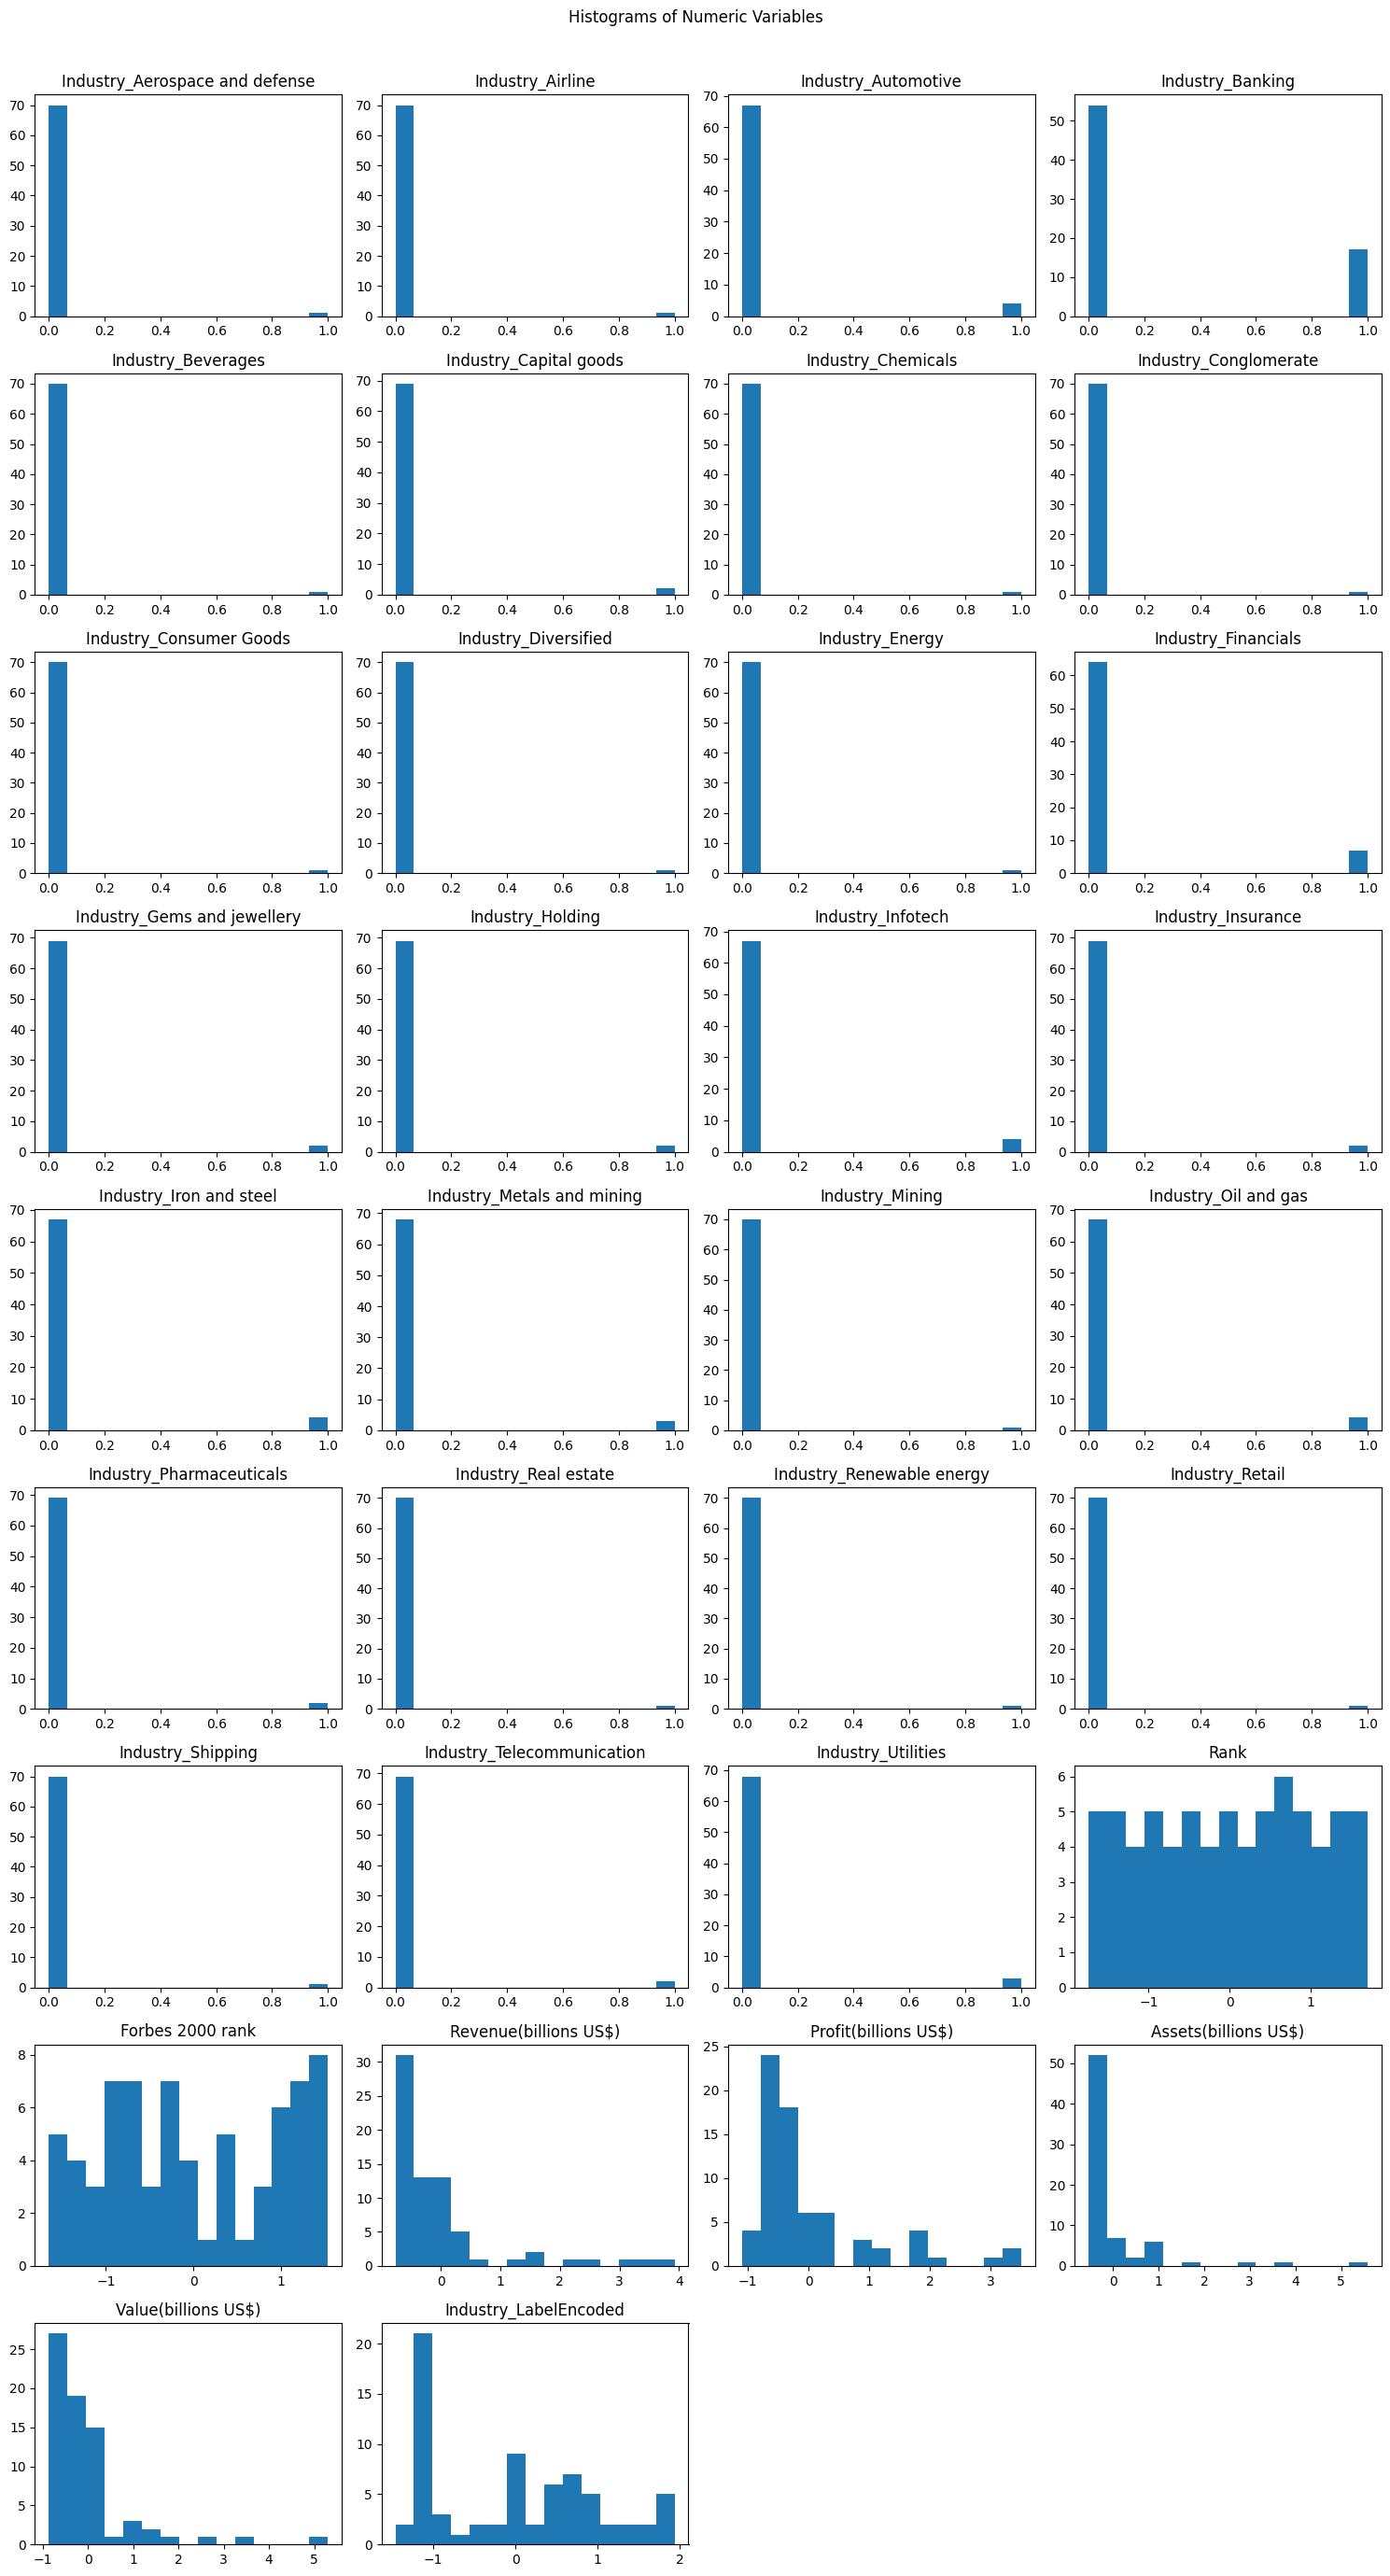

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
n_cols = 4 # Number of columns per figure
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate number of rows needed per figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3)) # Adjust figure size
# Flatten axes array for easy iteration
axes = axes.flatten()
# Plot histograms
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=15)
    axes[i].set_title(col)
# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.suptitle("Histograms of Numeric Variables", y=1.02) # Add a suptitle above all subplots
plt.show()

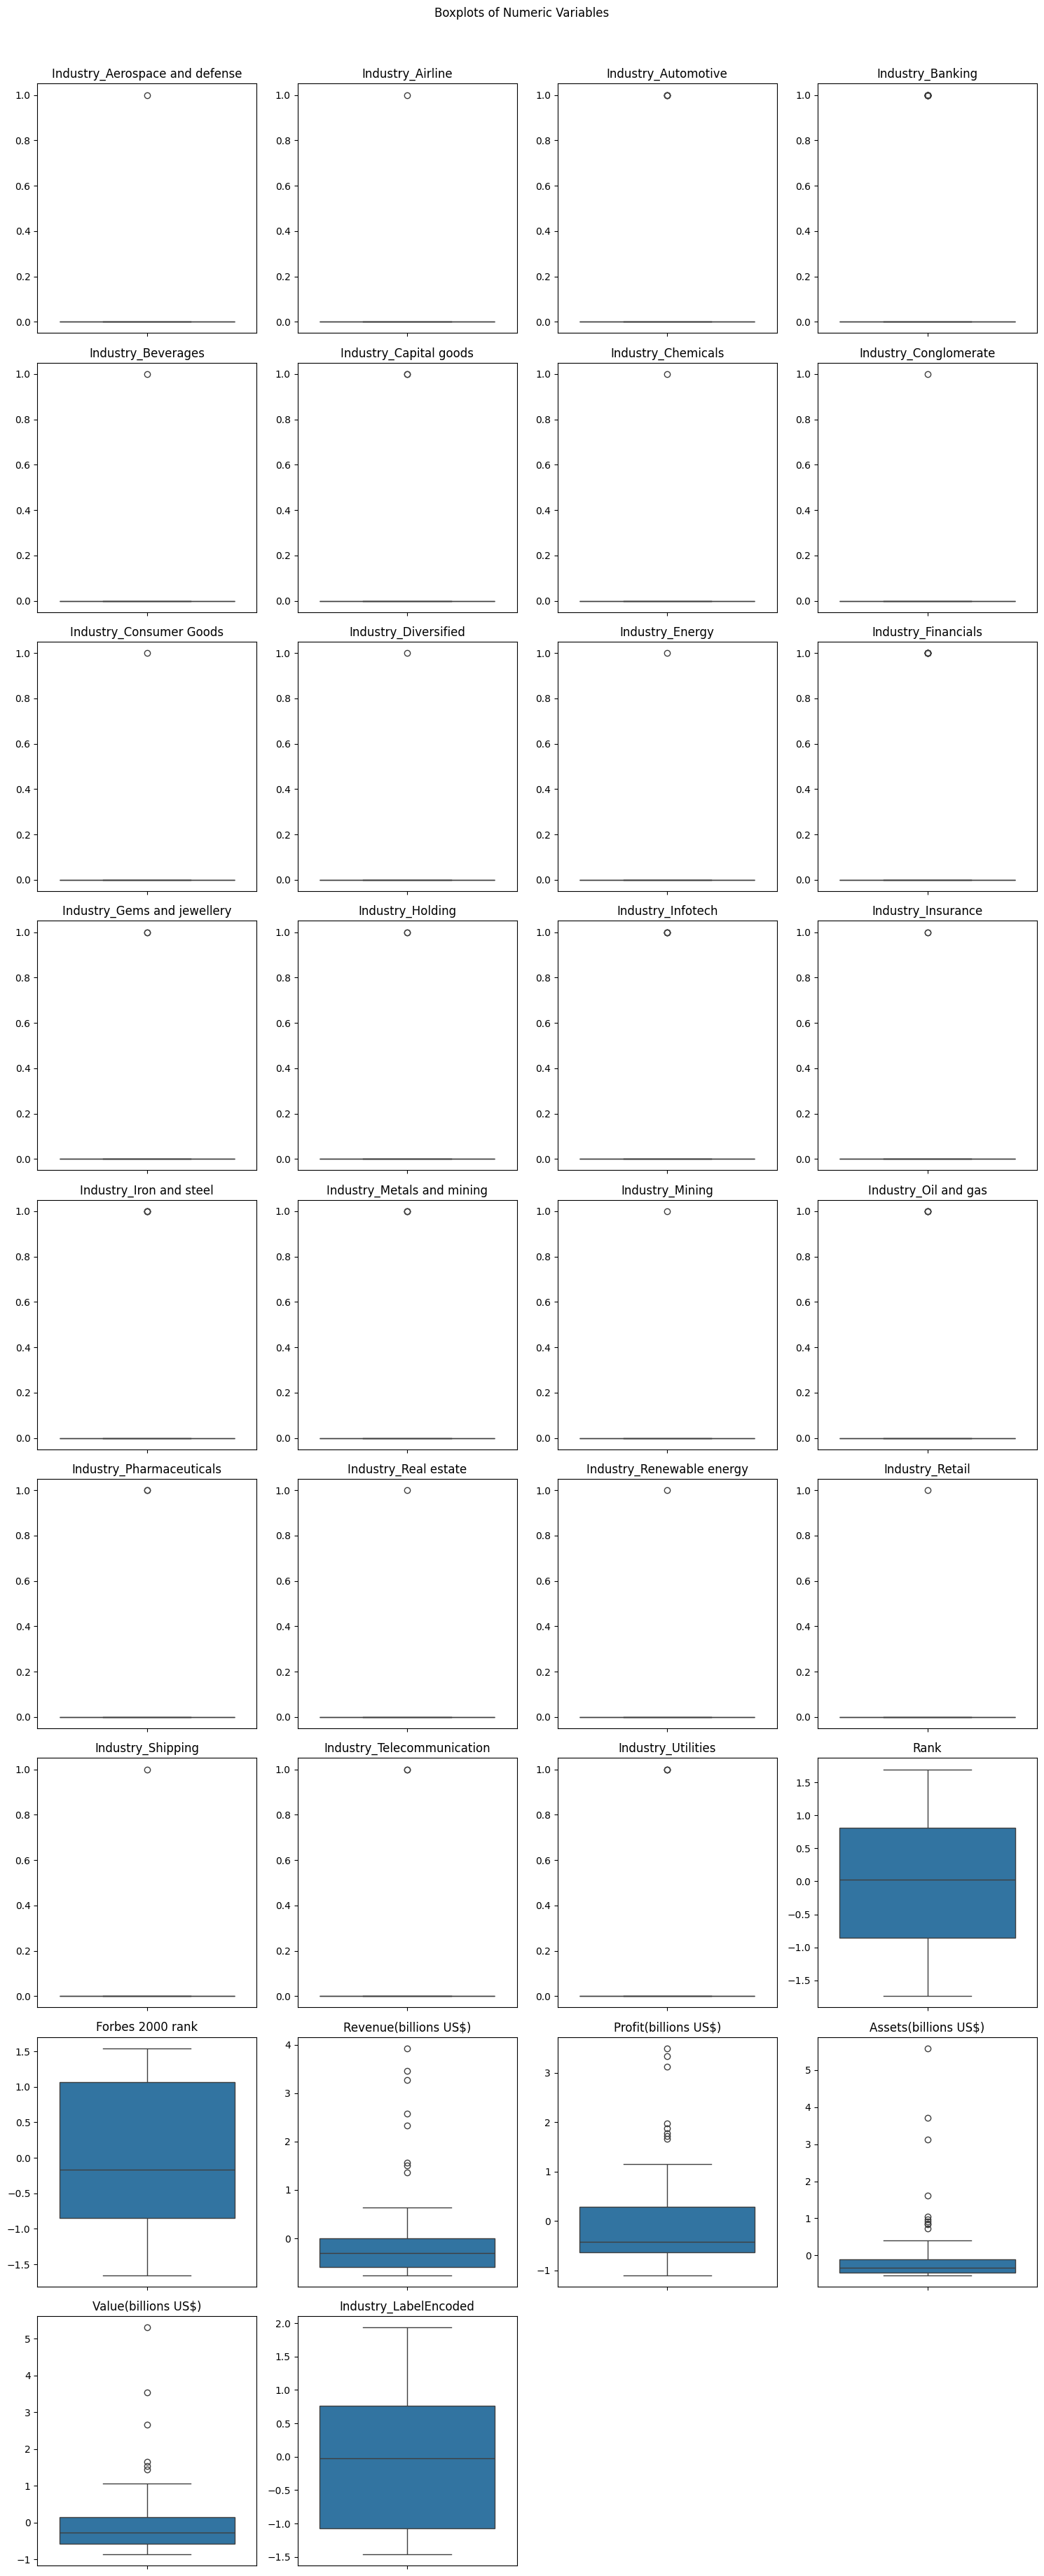

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
n_cols = 4 # Number of columns per figure
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate number of rows needed per figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4)) # Adjust figure size for boxplots
# Flatten axes array for easy iteration
axes = axes.flatten()
# Plot boxplots
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('') # Remove y-label to save space
# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.suptitle("Boxplots of Numeric Variables", y=1.02) # Add a suptitle above all subplots
plt.show()

In [ ]:
df_dropped = df.dropna()

In [ ]:
from scipy import stats
# Identify numerical columns to perform t-tests on
# Exclude Industry_LabelEncoded and one-hot encoded columns as they represent categories
numerical_cols_for_ttest = ['Rank', 'Forbes 2000 rank', 'Revenue(billions US$)', 'Profit(billions US$)', 'Assets(billions US$)', 'Value(billions US$)']
# Ensure the columns exist in the DataFrame
numerical_cols_for_ttest = [col for col in numerical_cols_for_ttest if col in df.columns]
if len(numerical_cols_for_ttest) >= 2:
    print("Performing t-tests between pairs of numerical columns:")
    for i in range(len(numerical_cols_for_ttest)):
        for j in range(i + 1, len(numerical_cols_for_ttest)):
            col1 = numerical_cols_for_ttest[i]
            col2 = numerical_cols_for_ttest[j]
            # Perform independent samples t-test
            # We need to handle potential NaNs, though we dropped them earlier for scaling
            # Using .dropna() is a safe practice here.
            t_stat, p_value = stats.ttest_ind(df[col1].dropna(), df[col2].dropna())
            print(f"\nT-test between '{col1}' and '{col2}':")
            print(f"  T-statistic: {t_stat:.4f}")
            print(f"  P-value: {p_value:.4f}")
else:
    print("Not enough numerical columns to perform t-tests.")

Performing t-tests between pairs of numerical columns:

T-test between 'Rank' and 'Forbes 2000 rank':
  T-statistic: 0.0000
  P-value: 1.0000

T-test between 'Rank' and 'Revenue(billions US$)':
  T-statistic: 0.0000
  P-value: 1.0000

T-test between 'Rank' and 'Profit(billions US$)':
  T-statistic: 0.0000
  P-value: 1.0000

T-test between 'Rank' and 'Assets(billions US$)':
  T-statistic: 0.0000
  P-value: 1.0000

T-test between 'Rank' and 'Value(billions US$)':
  T-statistic: 0.0000
  P-value: 1.0000

T-test between 'Forbes 2000 rank' and 'Revenue(billions US$)':
  T-statistic: -0.0000
  P-value: 1.0000

T-test between 'Forbes 2000 rank' and 'Profit(billions US$)':
  T-statistic: -0.0000
  P-value: 1.0000

T-test between 'Forbes 2000 rank' and 'Assets(billions US$)':
  T-statistic: -0.0000
  P-value: 1.0000

T-test between 'Forbes 2000 rank' and 'Value(billions US$)':
  T-statistic: -0.0000
  P-value: 1.0000

T-test between 'Revenue(billions US$)' and 'Profit(billions US$)':
  T-statis

In [ ]:
print("Descriptive Statistics:\n", desc_stats)
print("Skewness:\n", skewness)
print("Kurtosis:\n", kurtosis)
print("Correlation Matrix:\n", correlation_matrix)

Descriptive Statistics:
        Industry_Aerospace and defense  Industry_Airline  Industry_Automotive  \
count                       71.000000         71.000000            71.000000   
mean                         0.014085          0.014085             0.056338   
std                          0.118678          0.118678             0.232214   
min                          0.000000          0.000000             0.000000   
25%                          0.000000          0.000000             0.000000   
50%                          0.000000          0.000000             0.000000   
75%                          0.000000          0.000000             0.000000   
max                          1.000000          1.000000             1.000000   

       Industry_Banking  Industry_Beverages  Industry_Capital goods  \
count         71.000000           71.000000               71.000000   
mean           0.239437            0.014085                0.028169   
std            0.429777            0.1186

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

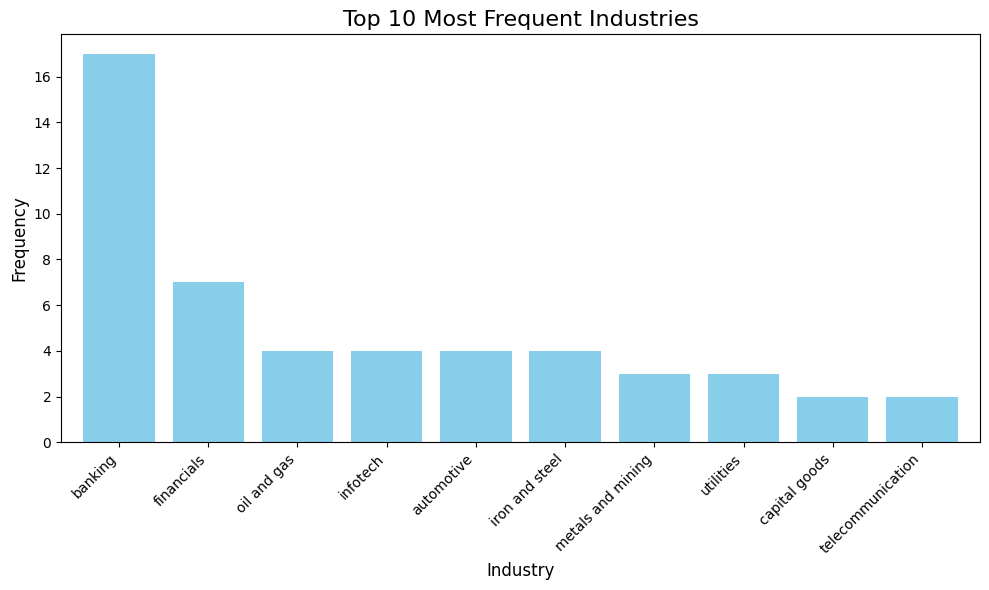

In [ ]:
# Calculate the value counts for the 'Industry' column and get the top 10
industry_value_counts = df['Industry'].value_counts().head(10)
# Create the bar plot
plt.figure(figsize=(10, 6)) # Adjusted figure size for better readability
industry_value_counts.plot(kind='bar', color='skyblue', width=0.8)
# Set title and labels
plt.title('Top 10 Most Frequent Industries', fontsize=16)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)
# Adjust layout to prevent labels from being cut off
plt.tight_layout()
# Display the plot
plt.show()

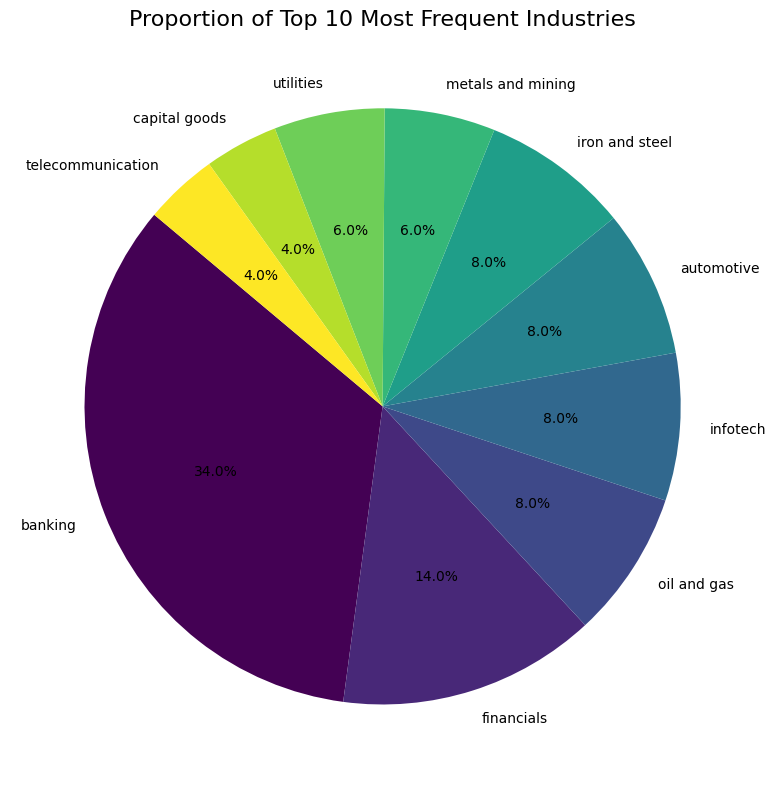

In [ ]:
# Use the value counts calculated in the previous cell
# industry_value_counts = df['Industry'].value_counts().head(10) # Assuming this was done in the previous cell
plt.figure(figsize=(8, 8)) # Adjusted figure size for better readability of a pie chart
industry_value_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colormap='viridis'
)
# Set title
plt.title('Proportion of Top 10 Most Frequent Industries', fontsize=16)
# Remove y-label as it's not relevant for a pie chart
plt.ylabel('')
# Adjust layout
plt.tight_layout()
# Display the plot
plt.show()

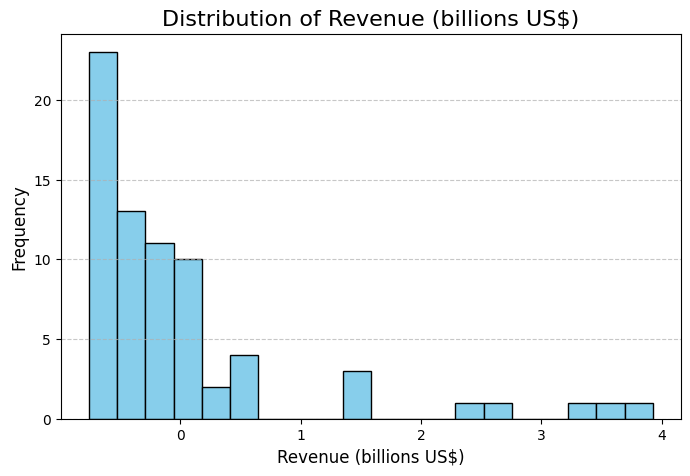

In [ ]:
plt.figure(figsize=(8, 5)) # Adjusted figure size
plt.hist(df['Revenue(billions US$)'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Revenue (billions US$)', fontsize=16)
plt.xlabel('Revenue (billions US$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

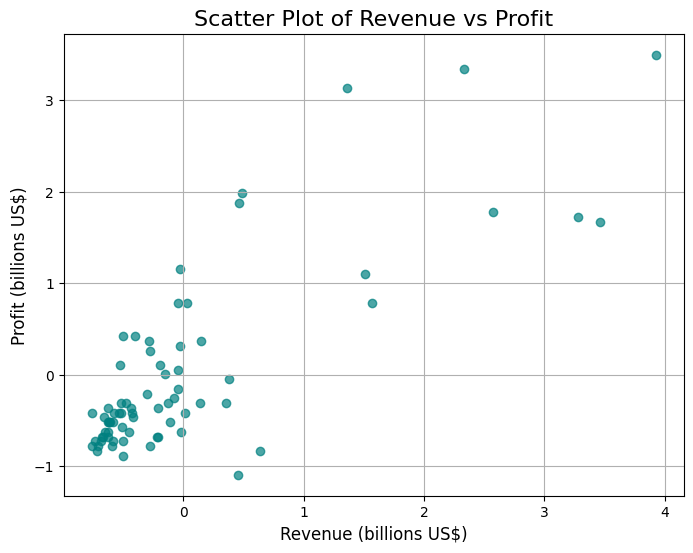

In [ ]:
plt.figure(figsize=(8, 6)) # Adjusted figure size
plt.scatter(df['Revenue(billions US$)'], df['Profit(billions US$)'], color='teal', alpha=0.7)
plt.title('Scatter Plot of Revenue vs Profit', fontsize=16)
plt.xlabel('Revenue (billions US$)', fontsize=12)
plt.ylabel('Profit (billions US$)', fontsize=12)
plt.grid(True)
plt.show()

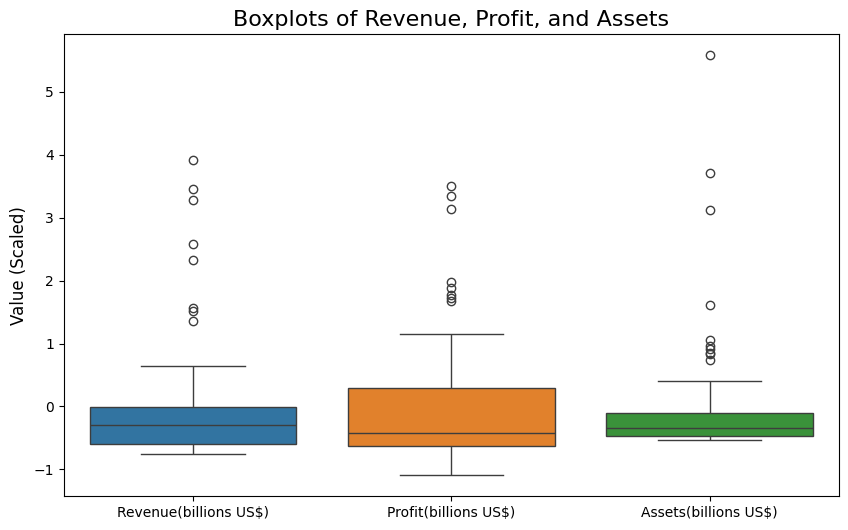

In [ ]:
plt.figure(figsize=(10, 6)) # Adjusted figure size
sns.boxplot(data=df[['Revenue(billions US$)', 'Profit(billions US$)', 'Assets(billions US$)']])
plt.title('Boxplots of Revenue, Profit, and Assets', fontsize=16)
plt.ylabel('Value (Scaled)', fontsize=12) # Indicate that values are scaled
plt.show()

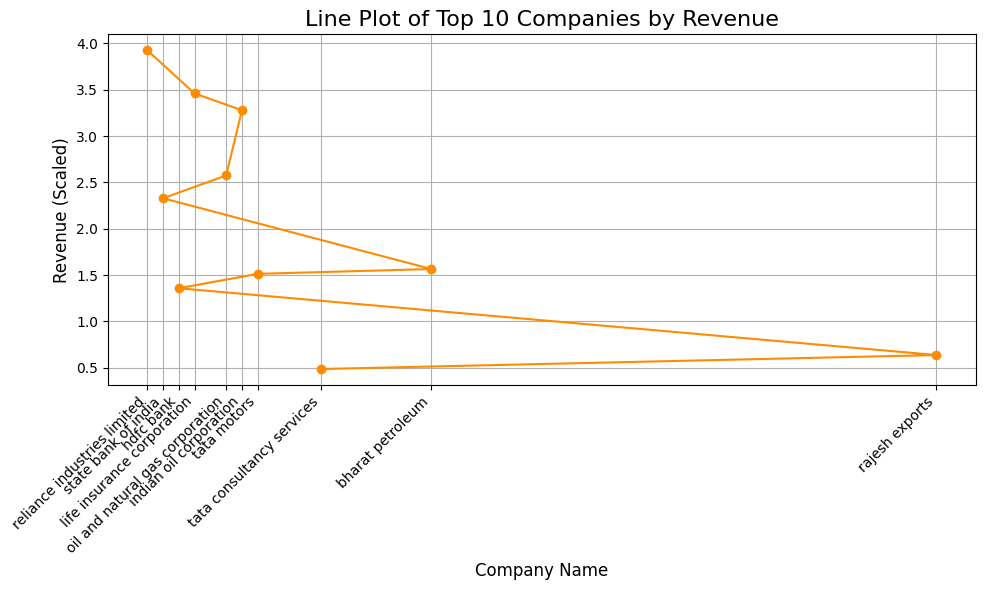

In [ ]:
# Find the top 10 companies by Revenue
top_10_revenue = df.nlargest(10, 'Revenue(billions US$)')
plt.figure(figsize=(10, 6)) # Adjusted figure size
plt.plot(top_10_revenue.index, top_10_revenue['Revenue(billions US$)'], color='darkorange', marker='o', linestyle='-')
# Add company names as x-axis labels for better context
plt.xticks(ticks=top_10_revenue.index, labels=top_10_revenue['Name'], rotation=45, ha='right', fontsize=10)
plt.title('Line Plot of Top 10 Companies by Revenue', fontsize=16)
plt.xlabel('Company Name', fontsize=12) # Changed xlabel to Company Name
plt.ylabel('Revenue (Scaled)', fontsize=12) # Indicate that values are scaled
plt.grid(True)
plt.tight_layout()
plt.show()

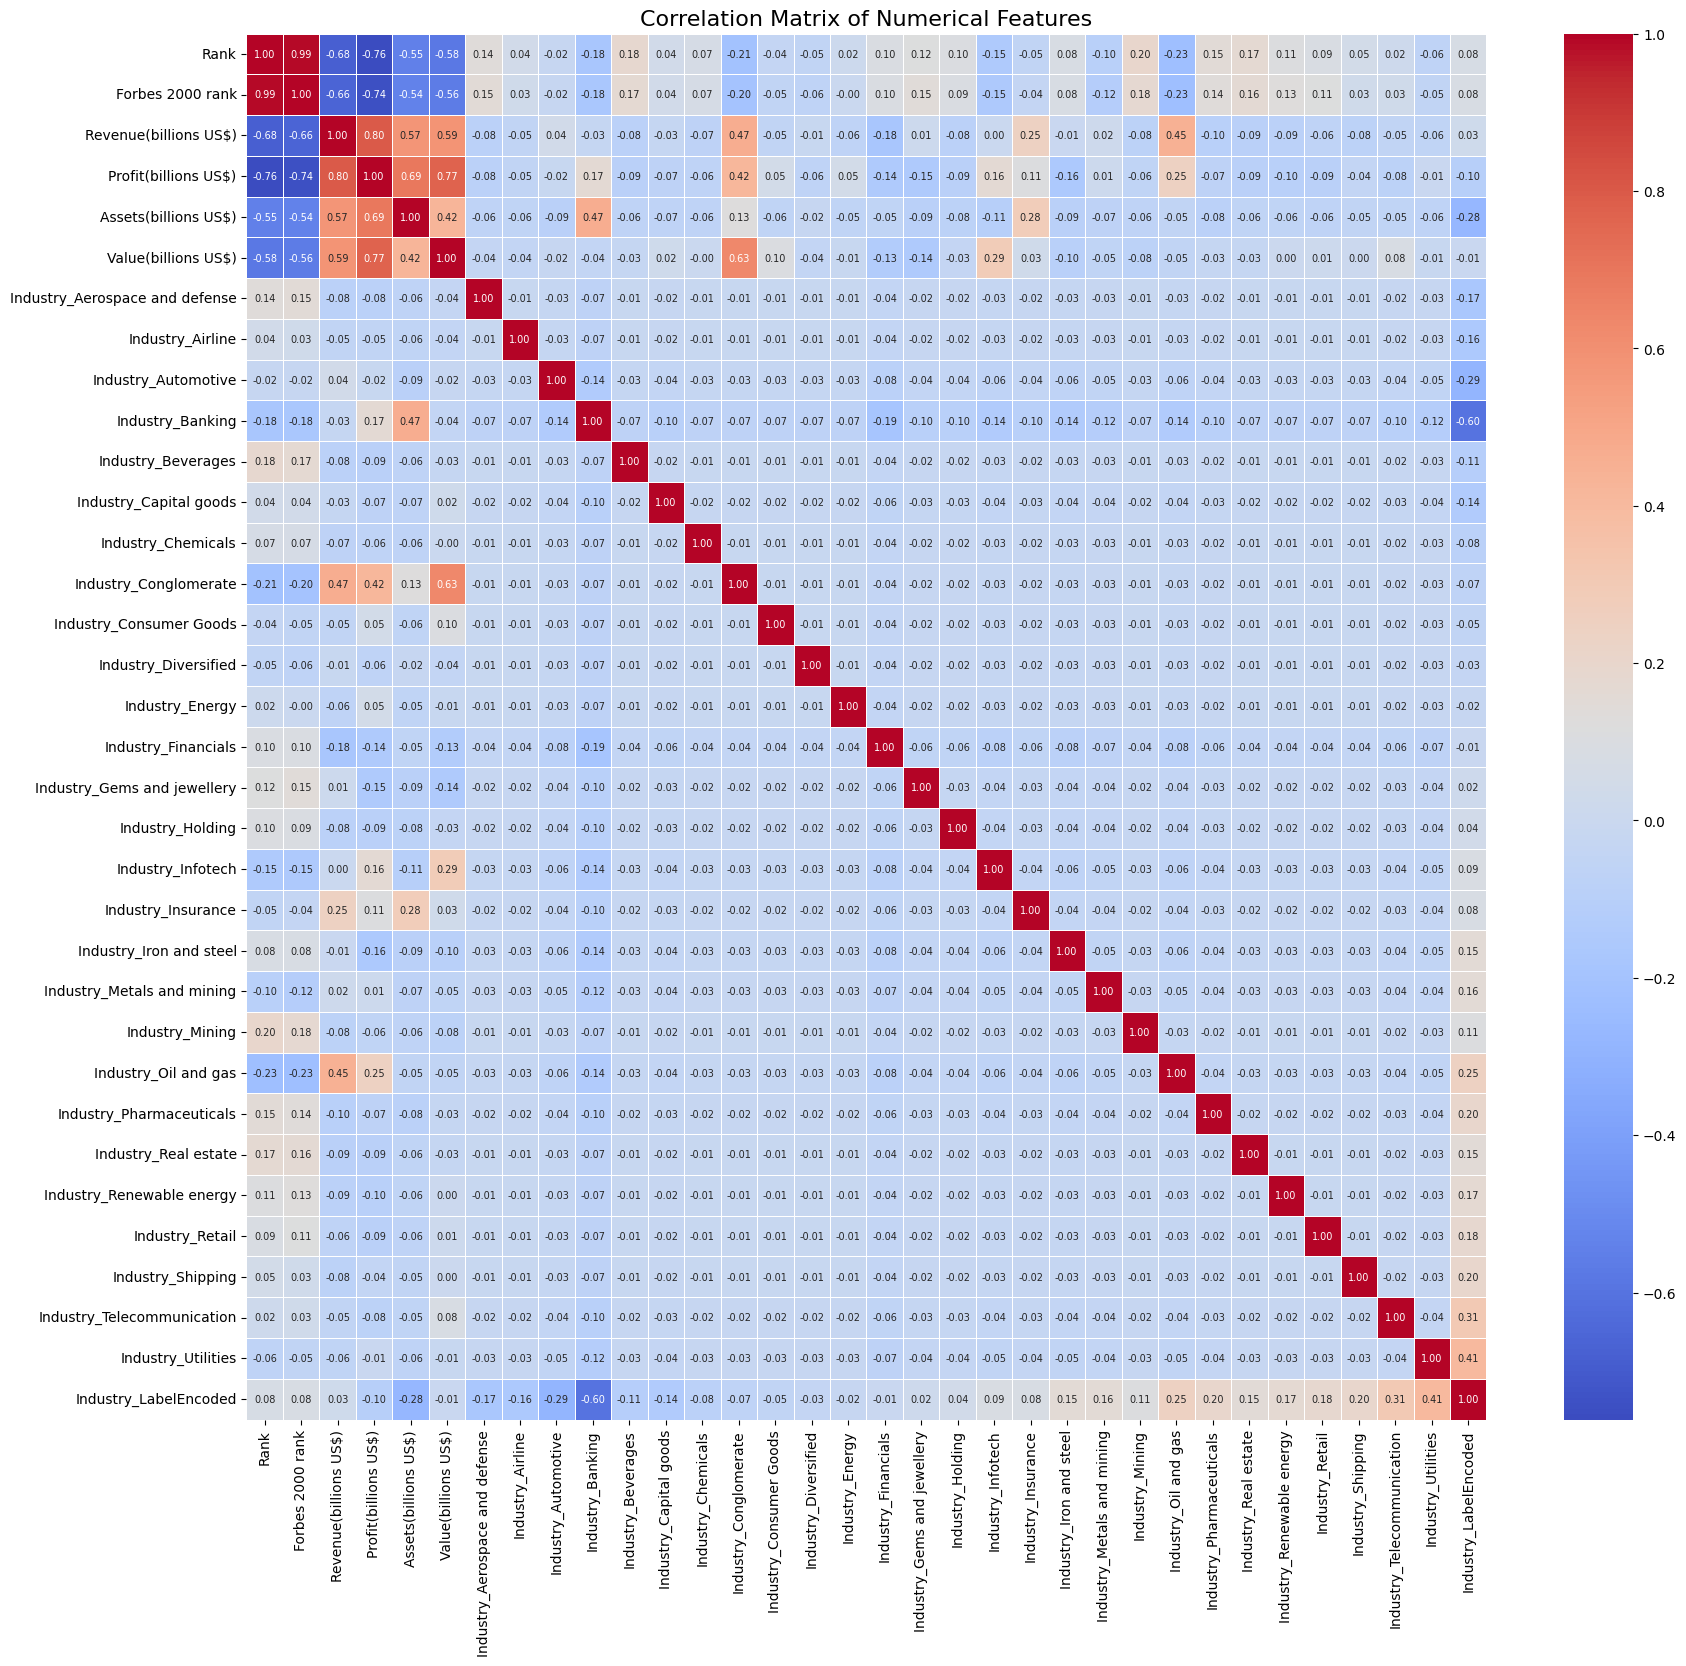

In [ ]:
# Assuming 'correlation_matrix' is already calculated from unique numerical features
# If not, you would recalculate it here:
# numerical_cols = df.select_dtypes(include=[np.number]).columns
# correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(20, 18)) # Adjusted figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 7}) # Adjusted annot_kws
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()